<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Búsqueda en Sistemas de Archivos: DFS y BFS 🗂️
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4f46e5; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Algoritmos de Búsqueda
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

---
## 1. El Problema: Buscar un Archivo Específico (1.16.5) 🔍

Retomamos el caso de *Constructora Horizonte Andino S.A.S.*: necesitamos encontrar el archivo **`informe_final.pdf`** dentro del servidor central de la empresa, **sin** usar ningún buscador del sistema operativo, programando nosotros mismos el recorrido.

En este cuaderno formalizamos el sistema de archivos simulado como una **clase reutilizable en Python** y construimos, de forma completa y funcional, los dos algoritmos de búsqueda no informada:

* **DFS** (*Depth-First Search* — búsqueda en profundidad): usa una **pila**.
* **BFS** (*Breadth-First Search* — búsqueda en anchura): usa una **cola**.

Todo el código vive también en el archivo reutilizable [`file_search.py`](file_search.py), ubicado en esta misma carpeta, para que puedas importarlo desde cualquier otro cuaderno o script.

---
## 2. Modelando el Sistema de Archivos: la clase `Nodo` (1.16.6) 🌳

Representamos cada carpeta o archivo como un objeto `Nodo`, con un `nombre`, un `tipo` (`"carpeta"` o `"archivo"`) y una lista de `hijos`. Esta es exactamente la noción de **estado** que discutimos en el cuaderno 00.

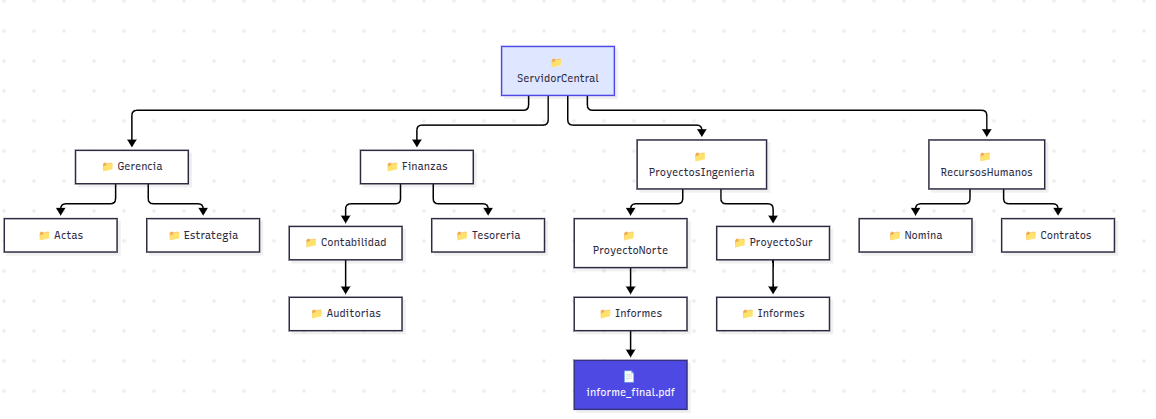

### Estructura general del código (1.16.6)

`file_search.py` expone:
1. `Nodo`: la clase que representa carpetas y archivos.
2. `construir_sistema_archivos()`: construye y devuelve la raíz del árbol de ejemplo anterior.
3. `dfs_buscar(raiz, nombre_objetivo)` y `bfs_buscar(raiz, nombre_objetivo)`: los dos algoritmos de búsqueda, cada uno devolviendo un diccionario con el resultado (¿se encontró?, camino, orden de exploración, nodos expandidos).
4. `imprimir_arbol()` y `resumen_resultado()`: utilidades de visualización.

Importemos el módulo y construyamos el árbol:

In [ ]:
import sys
sys.path.append('.')  # asegura que Python encuentre file_search.py en esta carpeta

from file_search import Nodo, construir_sistema_archivos, imprimir_arbol, dfs_buscar, bfs_buscar, resumen_resultado

raiz = construir_sistema_archivos()
print("Sistema de archivos simulado de Constructora Horizonte Andino S.A.S.:\n")
imprimir_arbol(raiz)

---
## 3. Implementación de DFS y BFS (código real, no pseudocódigo) 🧑‍💻

Ambas funciones viven en `file_search.py`. Usamos `inspect.getsource()` para **mostrar el código fuente real** que se está ejecutando, sin duplicarlo manualmente en el cuaderno (así garantizamos que lo que ves aquí es exactamente lo que corre).

In [ ]:
import inspect
print(inspect.getsource(dfs_buscar))

In [ ]:
print(inspect.getsource(bfs_buscar))

**Puntos clave de ambas implementaciones:**
* Ambas reciben la `raiz` del árbol y el `nombre_objetivo` a buscar.
* Ambas usan un conjunto `explorados` (guardando `id(nodo)`, la identidad del objeto en memoria) para no volver a procesar un nodo ya visitado — esta es la defensa contra ciclos que discutimos en el cuaderno 00.
* **DFS** usa una **pila** (`pila.pop()`, extrae el último elemento agregado — LIFO).
* **BFS** usa una **cola** (`frontera.popleft()`, extrae el primer elemento agregado — FIFO), y además marca un nodo como explorado en el momento en que lo **descubre** (no cuando lo expande), lo cual es clave para que BFS garantice el camino más corto en número de saltos.

---
## 4. Ejecutando y Comparando DFS vs. BFS 🏁

Busquemos `informe_final.pdf` con ambos algoritmos sobre el mismo árbol y comparemos el **orden de exploración** y el **camino encontrado**.

In [ ]:
objetivo = "informe_final.pdf"

resultado_dfs = dfs_buscar(raiz, objetivo)
resultado_bfs = bfs_buscar(raiz, objetivo)

print(resumen_resultado("DFS", resultado_dfs))
print(f"  Orden de exploración DFS ({len(resultado_dfs['orden_visita'])} nodos):")
print("  " + " → ".join(resultado_dfs["orden_visita"]))

print()
print(resumen_resultado("BFS", resultado_bfs))
print(f"  Orden de exploración BFS ({len(resultado_bfs['orden_visita'])} nodos):")
print("  " + " → ".join(resultado_bfs["orden_visita"]))

### 🔬 Análisis del resultado real

Al ejecutar la celda anterior sobre nuestro árbol de 35 nodos, obtenemos un resultado muy ilustrativo:

* **DFS expande 26 nodos**: como `ProyectosIngenieria` es el tercer hijo de la raíz, DFS primero se "hunde" completamente en `Gerencia` y luego en `Finanzas` (explorando *todas* sus subcarpetas y archivos, aunque no tengan nada que ver con el objetivo) antes de llegar por fin a `ProyectosIngenieria`.
* **BFS expande 35 nodos** (prácticamente el árbol completo): como el archivo está a profundidad 4, BFS debe agotar *todos* los nodos de profundidad 0, 1, 2 y 3 antes de poder siquiera considerar los nodos de profundidad 4, entre los cuales está nuestro objetivo.

**Ambos coinciden en el camino encontrado** (`ServidorCentral → ProyectosIngenieria → ProyectoNorte → Informes → informe_final.pdf`), porque en un **árbol** (sin ciclos ni rutas alternativas) sólo existe un único camino posible hacia cualquier nodo. La verdadera diferencia entre DFS y BFS, en este caso, no está en *qué* camino encuentran sino en *cuántos nodos deben expandir* y *cuánta memoria* necesitan para lograrlo — el trade-off que anticipamos en el cuaderno 00.

> ⚠️ Nota: el número exacto de nodos expandidos que veas en la celda anterior depende del orden en que se hayan definido los hijos de cada carpeta en `construir_sistema_archivos()`. Si tu resultado difiere ligeramente de estos números, no hay ningún error: simplemente refleja el mismo fenómeno con un orden de exploración distinto.

---
## 5. Camino Encontrado: Visualización Final 🗺️

In [ ]:
print("Camino final encontrado por ambos algoritmos:\n")
print("  " + "  ➜  ".join(resultado_bfs["camino"]))
print(f"\nProfundidad total: {resultado_bfs['profundidad']} saltos desde la raíz.")

assert resultado_dfs["encontrado"] and resultado_bfs["encontrado"]
assert resultado_dfs["camino"] == resultado_bfs["camino"]
print("\n✅ Verificación: DFS y BFS concuerdan en el camino (esperado, ya que el árbol no tiene ciclos).")

---
## 📌 Resumen / Puntos Clave

* Formalizamos el sistema de archivos como una clase `Nodo` (`nombre`, `tipo`, `hijos`), reutilizable desde [`file_search.py`](file_search.py).
* **DFS** usa una **pila** (LIFO): es económico en memoria, pero el orden de exploración depende fuertemente de la posición del objetivo dentro del árbol.
* **BFS** usa una **cola** (FIFO) y marca los nodos como explorados **al descubrirlos**: esto garantiza encontrar el camino con **menor número de saltos**, a costa de explorar (casi) todo el árbol si el objetivo está en un nivel profundo.
* En un **árbol** (sin rutas alternativas), DFS y BFS siempre encuentran el **mismo camino único**; la diferencia real está en el **número de nodos expandidos** y en el **consumo de memoria**.
* Ninguno de los dos algoritmos usa ninguna pista sobre el *nombre* del archivo que buscamos: eso es precisamente lo que agregaremos con la búsqueda informada en los próximos dos cuadernos.

### 🧠 Autoevaluación

1. En la ejecución real de este cuaderno, ¿qué algoritmo expandió menos nodos: DFS o BFS? ¿Es este resultado una garantía general o depende de la posición del objetivo en el árbol? Justifica tu respuesta.
2. Modifica mentalmente el árbol para que `informe_final.pdf` fuera el **primer** hijo de la raíz en lugar del tercero. ¿Cómo cambiaría el número de nodos expandidos por DFS? ¿Y por BFS?
3. ¿Por qué BFS marca un nodo como "explorado" en el momento de **descubrirlo** (agregarlo a la frontera) y no en el momento de **expandirlo**? ¿Qué problema evita esta decisión de diseño?
4. Si quisieras encontrar **todas** las coincidencias de un patrón (por ejemplo, todos los archivos que empiezan por `informe_`) en lugar de una sola, ¿qué cambiarías en `dfs_buscar` o `bfs_buscar`?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial — Módulo 04: Algoritmos de Búsqueda</i>
  </p>
</div>